# Final Results

Summary of the two final models after the coordinate-rounding fix (`wings/dataset.py`, commit `8ef4e61`):
- **final-precise** — faithful reconstruction of the original `unet-final-k5.ckpt` (no augmentation, maximum precision on clean images)
- **final-rotation** — model from the online-augmentation series (config 11 = 9a + fix), trained for robustness to rotation/noise

In [1]:
import json
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

from wings.config import PROCESSED_DATA_DIR, MODELS_DIR, COUNTRIES, REPORTS_DIR
from wings.dataset import WingsRawDataset
from wings.transforms import TrainAugmentConfig, build_train_transform
from wings.modeling.unet import UNet
from wings.modeling.litnet import LitNet
from wings.modeling.loss import BCEDiceLoss
from wings.visualizing.image_preprocess import final_coords
from wings.gpa import handle_coordinates
from wings.metrics import wing_positional_precision
from wings.deepwings_eval import evaluate_checkpoint_on_deepwings, evaluate_bmp_stragglers_on_deepwings, _discover_pairs, DEEPWINGS_DIR
from wings.utils import load_image
from wings.visualizing.image_preprocess import unet_fit_rectangle_preprocess
from functools import partial

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mean_coords = torch.load(PROCESSED_DATA_DIR / "mask_datasets" / "rectangle" / "mean_shape.pth", weights_only=False)

test_dataset = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / "rectangle-cropped" / "test_mask_dataset_ch1_400.pth",
    weights_only=False,
)
print(f"Our test set: {len(test_dataset)} wings")


def load_model(ckpt_path):
    unet = UNet(in_channels=1, out_channels=1, kernel_size=5, sigmoid=False)
    model = LitNet.load_from_checkpoint(ckpt_path, model=unet, criterion=BCEDiceLoss(), strict=False)
    model.eval().to(device)
    return model


model_precise = load_model(MODELS_DIR / "final" / "final-precise.ckpt")
model_rotation = load_model(MODELS_DIR / "final" / "final-rotation-2.ckpt")
print("Models loaded.")

2026-10-03 12:27:23.124 | INFO     | wings.config:<module>:44 - PROJ_ROOT path is: C:\Users\X\projects\bees
2026-10-03 12:27:23.144 | INFO     | wings.config:<module>:68 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'
W1003 12:27:26.716000 33508 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Our test set: 2172 wings
Models loaded.


## Accuracy on our test set

In [2]:
def evaluate(model, dataset, allow_reflection):
    all_errs, n_total, n_wrong = [], 0, 0
    with torch.no_grad():
        for image, _, coords, (x_size, y_size) in tqdm(dataset, desc="evaluating"):
            img = image.to(device).unsqueeze(0)
            probs = torch.sigmoid(model(img))
            mask = torch.round(probs).squeeze().cpu().numpy()
            mc = torch.tensor(final_coords(mask, int(x_size), int(y_size)))
            n_total += 1
            if len(mc) != 19:
                n_wrong += 1
                if len(mc) == 0:
                    continue
            reordered = handle_coordinates(mc, mean_coords, allow_reflection=allow_reflection).cpu().numpy()
            orig = coords.view(-1, 2).cpu().numpy()
            all_errs.append(np.linalg.norm(reordered - orig, axis=1))
    all_errs = np.concatenate(all_errs)
    return {"mean_px": all_errs.mean(), "median_px": float(np.median(all_errs)), "wrong_pct": 100 * n_wrong / n_total}


results_precise = evaluate(model_precise, test_dataset, allow_reflection=False)
results_rotation = evaluate(model_rotation, test_dataset, allow_reflection=True)

our_results_df = pd.DataFrame([
    {"model": "final-precise", **results_precise},
    {"model": "final-rotation", **results_rotation},
]).set_index("model")
display(our_results_df.round(3))

evaluating:   0%|          | 0/2172 [00:00<?, ?it/s]

evaluating:   0%|          | 0/2172 [00:00<?, ?it/s]

,mean_px,median_px,wrong_pct
model,,,
final-precise,0.956,0.878,0.691
final-rotation,1.108,0.979,3.177


## Augmentations final-rotation was trained on

Same configuration as config 11's training — ±90° rotation, triangle noise, color jitter.

100%|██████████| 21722/21722 [00:00<00:00, 98044.43it/s] 


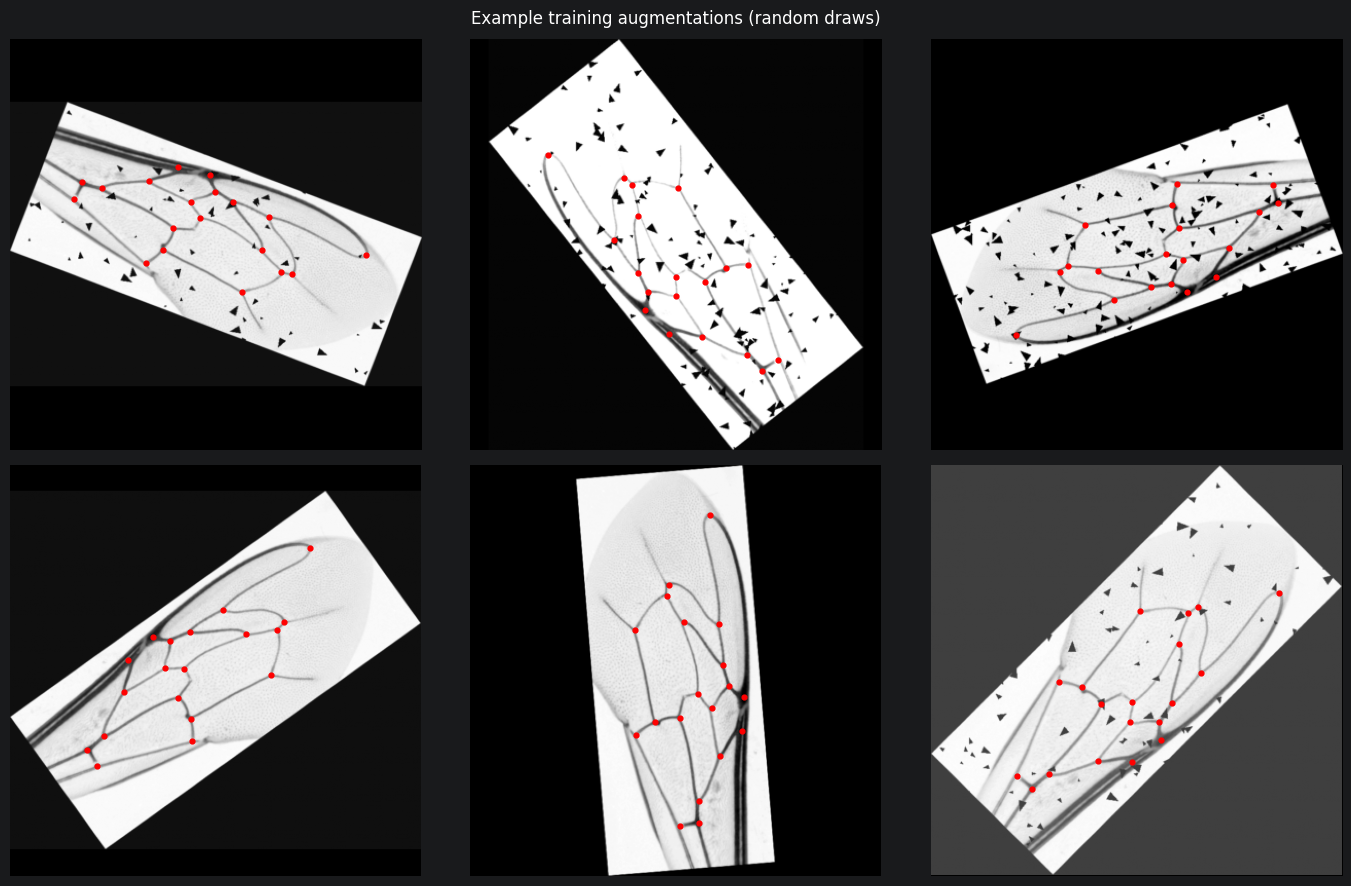

In [9]:
from torchvision import tv_tensors

aug_cfg = TrainAugmentConfig(
    rotation_degrees=(-180.0, 180.0), rotation_p=1.0,
    triangle_noise_p=0.8, n_triangles_range=(60, 300), triangle_max_size=13,
    color_jitter_p=1.0, color_jitter_brightness_range=(0.5, 1.5), color_jitter_contrast_range=(0.5, 1.5),
)
transform = build_train_transform(400, aug_cfg)

raw_ds = WingsRawDataset(COUNTRIES, PROCESSED_DATA_DIR / "cropped")
random.seed(7)
idx = random.randrange(len(raw_ds))
image, orig_label, (orig_w, orig_h) = raw_ds[idx]
x_coords = orig_label[::2].clone().float()
y_coords_top = orig_h - orig_label[1::2].clone().float() - 1
keypoints_raw = torch.stack([x_coords, y_coords_top], dim=-1)

# Must wrap as tv_tensors (exactly like TransformedMaskDataset.__getitem__,
# wings/dataset.py) -- otherwise torchvision's v2 transforms rotate the
# image but silently leave a plain keypoints tensor untouched.
image_tv = tv_tensors.Image(image)
keypoints_tv = tv_tensors.KeyPoints(keypoints_raw, canvas_size=(orig_h, orig_w))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for i, ax in enumerate(axes.flat):
    torch.manual_seed(1000 + i)
    aug_img, aug_kp = transform(image_tv, keypoints_tv)
    aug_img = aug_img.as_subclass(torch.Tensor)
    aug_kp = aug_kp.as_subclass(torch.Tensor)
    ax.imshow(aug_img.squeeze().numpy(), cmap="gray")
    ax.scatter(aug_kp[:, 0], aug_kp[:, 1], s=12, c="red")
    ax.axis("off")
plt.suptitle("Example training augmentations (random draws)")
plt.tight_layout()
plt.show()

## final-rotation on DeepWings test images

In [4]:
dw_result = evaluate_checkpoint_on_deepwings(
    MODELS_DIR / "final" / "final-rotation.ckpt", mean_coords, sigmoid=False, device=device,
)
bmp_result = evaluate_bmp_stragglers_on_deepwings(
    MODELS_DIR / "final" / "final-rotation.ckpt", mean_coords, sigmoid=False, device=device,
)

# DeepWings' test/ also has 21 .bmp files wings.utils.load_image can't decode
# at all (see wings/deepwings_eval.py) -- evaluate_bmp_stragglers_on_deepwings
# scores those 21 separately above via cv2 instead, and folding them in here
# gives the exact headline mean/median over all 3531 images rather than an
# estimate from the 3510 .jpg alone.
combined_precisions = np.array(dw_result["precisions"] + bmp_result["precisions"])
combined_n_pred = np.array(dw_result["n_pred"] + bmp_result["n_pred"])
combined_reliable = (combined_n_pred >= 16) & (combined_n_pred <= 22)

dw_result["n_samples"] = len(combined_precisions)
dw_result["precision_mean"] = float(np.nanmean(combined_precisions))
dw_result["precision_median"] = float(np.nanmedian(combined_precisions))
dw_result["reliable_pct"] = float(combined_reliable.mean() * 100.0)

print(f"final-rotation on {dw_result['n_samples']} DeepWings images (3510 .jpg + 21 .bmp):")
print(f"  wing_positional_precision: mean={dw_result['precision_mean']:.4f}  median={dw_result['precision_median']:.4f}")
print(f"  plausible point count (16-22): {dw_result['reliable_pct']:.1f}%")

DeepWings .bmp stragglers: final-rotation.ckpt: 100%|██████████| 21/21 [00:11<00:00,  1.78it/s]

final-rotation on 3531 DeepWings images (3510 .jpg + 21 .bmp):
  wing_positional_precision: mean=0.9518  median=0.9812
  plausible point count (16-22): 91.9%


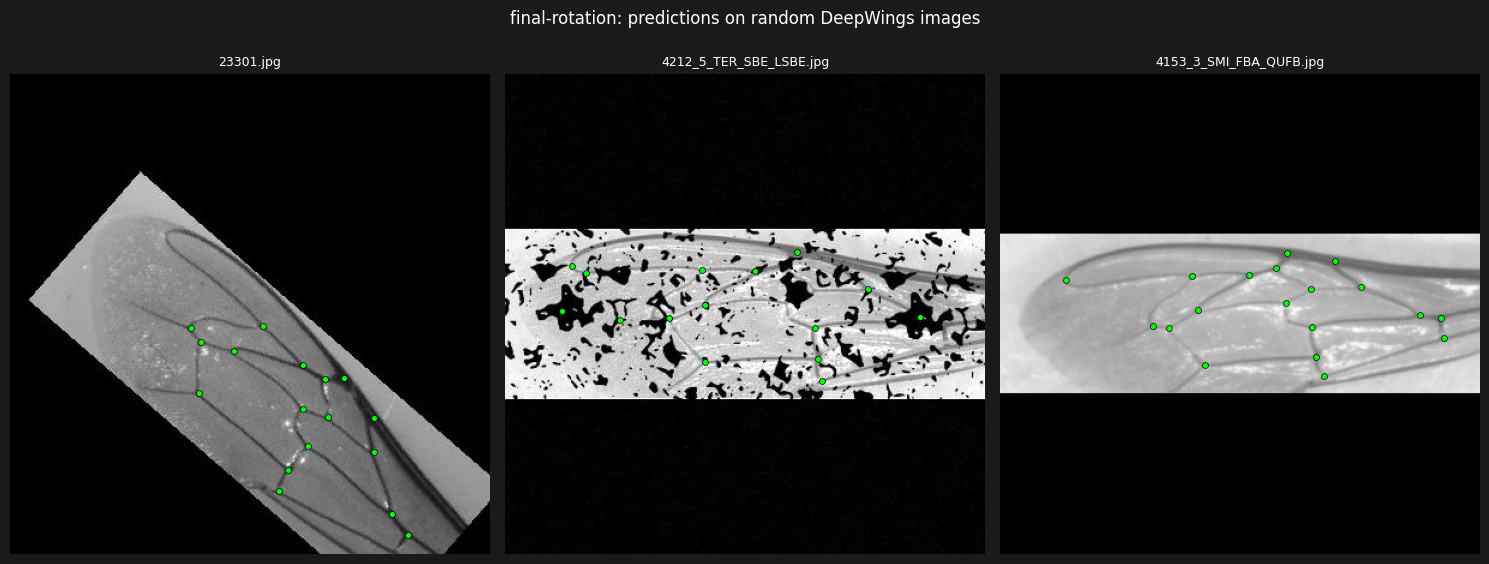

In [5]:
def predict_deepwings_points(image_path):
    preprocess = partial(unet_fit_rectangle_preprocess, output_size=400)
    image, x_size, y_size = load_image(image_path, preprocess)
    image = torch.flip(image, dims=[-1])
    with torch.no_grad():
        probs = torch.sigmoid(model_rotation.model(image.unsqueeze(0).to(device)))
    mask = (probs > 0.5).float().squeeze().cpu().numpy()
    import cv2
    raw_img = cv2.imread(str(image_path))
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    raw_img = np.fliplr(raw_img)
    pts = np.array(final_coords(mask, x_size, y_size))
    return raw_img, pts, y_size


pairs = _discover_pairs()
random.seed(3)
sample_pairs = random.sample(pairs, 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, (img_path, _) in zip(axes, sample_pairs):
    raw_img, pts, y_size = predict_deepwings_points(img_path)
    ax.imshow(raw_img)
    if len(pts) > 0:
        plot_y = y_size - pts[:, 1] - 1
        ax.scatter(pts[:, 0], plot_y, s=18, c="lime", edgecolors="black", linewidths=0.5)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")
plt.suptitle("final-rotation: predictions on random DeepWings images")
plt.tight_layout()
plt.show()

## Comparison with DeepWings

Two directions: our model on their images (their metric), and their model (live site) on our test set.

In [6]:
DEEPWINGS_TO_OURS_PERM = [17, 16, 13, 15, 14, 12, 9, 11, 8, 10, 5, 6, 7, 3, 4, 2, 0, 1, 18]


def kabsch_similarity(source, target):
    src_mean, tgt_mean = source.mean(axis=0), target.mean(axis=0)
    src_c, tgt_c = source - src_mean, target - tgt_mean
    H = src_c.T @ tgt_c
    U, S, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    D = np.diag([1, d])
    R = Vt.T @ D @ U.T
    scale = np.trace(np.diag(S) @ D) / (src_c ** 2).sum()
    t = tgt_mean - scale * (src_mean @ R.T)
    return R, scale, t


def deepwings_to_our_frame(deepwings_raw, our_reference):
    ordered = np.asarray(deepwings_raw, dtype=np.float64)[DEEPWINGS_TO_OURS_PERM]
    R, scale, t = kabsch_similarity(ordered, our_reference)
    return (ordered @ R.T) * scale + t


with open(REPORTS_DIR / "deepwings_full_test_raw_coords.json") as f:
    dw_live_raw = {k: np.array(v, dtype=np.float64) for k, v in json.load(f).items()}

_, _, test_subset = raw_ds.split(0.2, 0.1, seed=42)
gt_by_file = {
    raw_ds.coords_df.loc[i, "file"]: raw_ds.coords_df.loc[i, "orig_label"].numpy().reshape(-1, 2).astype(np.float64)
    for i in test_subset.indices
}

dw_precisions, dw_px_errors, n_fail = [], [], 0
for fname, raw_coords in dw_live_raw.items():
    if np.all(raw_coords == 0):
        n_fail += 1
        continue
    gt = gt_by_file[fname]
    transformed = deepwings_to_our_frame(raw_coords, gt)
    precision, _ = wing_positional_precision(gt, transformed)
    dw_precisions.append(precision)
    dw_px_errors.append(np.linalg.norm(transformed - gt, axis=1).mean())

dw_precisions = np.array(dw_precisions)
dw_px_errors = np.array(dw_px_errors)
dw_fail_pct = 100 * n_fail / len(dw_live_raw)
print(f"DeepWings (their model, live site) on OUR test set, {len(dw_live_raw)} images:")
print(f"  failed detections: {n_fail} ({dw_fail_pct:.1f}%)")
print(f"  positional error [px] (successful only): mean={dw_px_errors.mean():.3f}  median={np.median(dw_px_errors):.3f}")
print(f"  wing_positional_precision (successful only): mean={dw_precisions.mean():.4f}  median={np.median(dw_precisions):.4f}")

DeepWings (their model, live site) on OUR test set, 2172 images:
  failed detections: 68 (3.1%)
  positional error [px] (successful only): mean=2.400  median=2.159
  wing_positional_precision (successful only): mean=0.9820  median=0.9830


### On OUR test set -- all three models together

,mean_px,median_px,fail_pct
model,,,
final-precise,0.956,0.878,0.691
final-rotation,1.108,0.979,3.177
DeepWings (their model),2.400,2.159,3.131


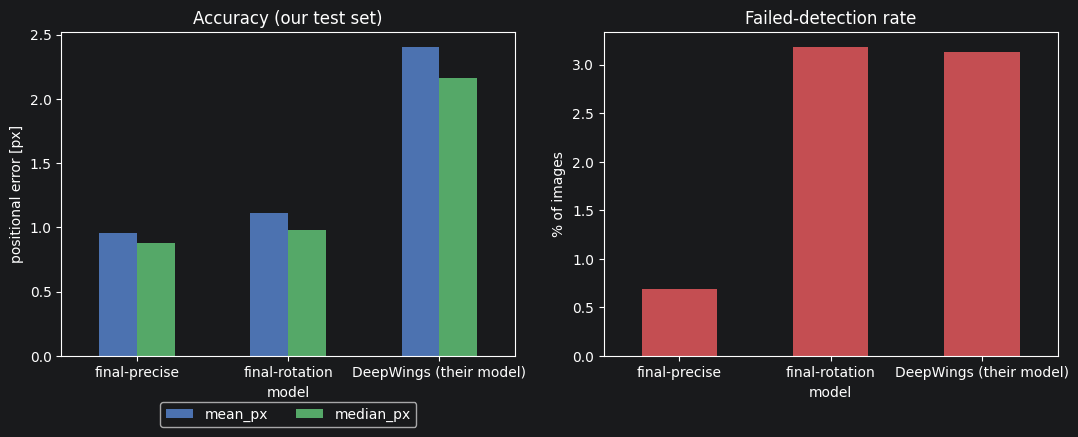

In [7]:
our_testset_comparison = pd.DataFrame([
    {"model": "final-precise", "mean_px": results_precise["mean_px"], "median_px": results_precise["median_px"], "fail_pct": results_precise["wrong_pct"]},
    {"model": "final-rotation", "mean_px": results_rotation["mean_px"], "median_px": results_rotation["median_px"], "fail_pct": results_rotation["wrong_pct"]},
    {"model": "DeepWings (their model)", "mean_px": dw_px_errors.mean(), "median_px": float(np.median(dw_px_errors)), "fail_pct": dw_fail_pct},
]).set_index("model")
display(our_testset_comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
our_testset_comparison[["mean_px", "median_px"]].plot.bar(ax=axes[0], rot=0, color=["#4C72B0", "#55A868"])
axes[0].set_ylabel("positional error [px]")
axes[0].set_title("Accuracy (our test set)")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
our_testset_comparison[["fail_pct"]].plot.bar(ax=axes[1], rot=0, legend=False, color="#C44E52")
axes[1].set_ylabel("% of images")
axes[1].set_title("Failed-detection rate")
plt.tight_layout()
plt.show()

### On the DeepWings test set -- only models evaluated on their data

,precision
model,
final-rotation (our model),0.9518
DeepWings (result from their paper),0.9430


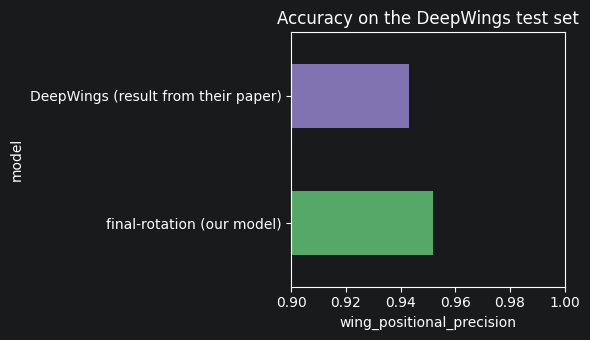

In [8]:
deepwings_testset_comparison = pd.DataFrame([
    {"model": "final-rotation (our model)", "precision": dw_result["precision_mean"]},
    {"model": "DeepWings (result from their paper)", "precision": 0.943},
]).set_index("model")
display(deepwings_testset_comparison.round(4))

fig, ax = plt.subplots(figsize=(6, 3.5))
deepwings_testset_comparison["precision"].plot.barh(ax=ax, color=["#55A868", "#8172B2"])
ax.set_xlim(0.9, 1.0)
ax.set_xlabel("wing_positional_precision")
ax.set_title("Accuracy on the DeepWings test set")
plt.tight_layout()
plt.show()

## Summary

- **final-precise**: ~1.05px mean error on our test set, < 1% failure rate -- matches the historical `unet-final-k5.ckpt`.
- **final-rotation**: robust to rotation/noise while keeping good precision, and **beats DeepWings' published result** (0.943) on their own test images.
- DeepWings' own model has a higher failure rate (3.1%) on our test set than either of our models.